# Mundiales 2018, 2022 y 2026
## Preparación de datos y entrada al análisis supervisado

Trabajaremos exclusivamente con la fase de grupos. Los archivos contienen errores deliberados. No uses la base del profesor.

## Objetivos

- Perfilar datos.
- Estandarizar esquemas.
- Limpiar fechas, equipos, goles y marcadores.
- Eliminar duplicados con criterio.
- Comparar torneos mediante tasas.
- Construir variables conocidas antes de cada partido.
- Entrenar un primer clasificador y detectar fuga de información.

In [1]:
from pathlib import Path
import re
import unicodedata

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay

DATA = Path('../datos')
pd.set_option('display.max_columns', 50)

## Cargar los tres archivos

In [3]:
d18 = pd.read_csv(DATA / 'mundial_2018_sucio.csv', dtype=str)
d22 = pd.read_csv(DATA / 'mundial_2022_sucio.csv', dtype=str)
d26 = pd.read_csv(DATA / 'mundial_2026_sucio.csv', dtype=str)

# TODO: muestra las dimensiones y las primeras filas de cada archivo.
for nombre, df in [('2018', d18), ('2022', d22), ('2026', d26)]:
    print(nombre, df.shape)
    display(df.head())



2018 (50, 16)


,ID Partido,Año,Fase,Grupo,Jornada,Fecha,Hora,Equipo Local,Equipo Visitante,Goles Local,Goles Visitante,Marcador,Anfitrión Local,Estadio,Ciudad,Fuente
0,M-2018-01,2018,Fase de grupos,Grupo A,1,2018-06-14,18:00,russia,KSA,5 goles,NaN,5-0,Sí,Luzhniki Stadium,Moscow,https://github.com/jfjelstul/worldcup
1,M-2018-02,2018,GROUP STAGE,A,1,15/06/2018,17:00,Egypt,Uruguay,0,1,0–1,0,Central Stadium,Yekaterinburg,https://github.com/jfjelstul/worldcup
2,M-2018-03,2018,grupos,group-b,1,06/15/2018,18:00,Morocco,"Iran, I.R.",0,1,0 : 1,FALSE,Krestovsky Stadium,Saint Petersburg,https://github.com/jfjelstul/worldcup
3,M-2018-04,2018,1ra fase,Grupo B,1,15-06-18,21:00,Portugal,España,3,3,3 x 3,no,Fisht Olympic Stadium,Sochi,https://github.com/jfjelstul/worldcup
4,M-2018-05,2018,Fase de grupos,C,1,"Jun 16, 2018",13:00,France,Australia,2,1,2—1,No,Kazan Arena,Kazan,https://github.com/jfjelstul/worldcup


2022 (51, 16)


,match_id,WorldCup,stage,group_name,match_day,date,local,visitor,home_score,away_score,score_text,home_host,venue,city_name,comentario,source_url
0,M-2022-01,2022,group,Group A,1,2022-11-20,Qatar,Ecuador,NaN,2,0 : 2,1,Al Bayt Stadium,Al Khor,ok,https://github.com/jfjelstul/worldcup
1,M-2022-02,2022,Group Stage,B,1,21/11/2022,England,IR Iran,6,2,6 x 2,FALSE,Khalifa International Stadium,Al Rayyan,NaN,https://github.com/jfjelstul/worldcup
2,M-2022-03,2022,Fase grupos,Grupo A,1,11/21/2022,Senegal,Netherlands,0,2,0—2,no,Al Thumama Stadium,Doha,revisar,https://github.com/jfjelstul/worldcup
3,M-2022-04,2022,group,B,1,21-11-22,United States,Wales,1,1,1-1,No,Ahmad bin Ali Stadium,Al Rayyan,dato importado,https://github.com/jfjelstul/worldcup
4,M-2022-05,2022,Group Stage,Group C,1,"Nov 22, 2022",Argentina,KSA,1,2,1–2,0,Lusail Stadium,Lusail,ok,https://github.com/jfjelstul/worldcup


2026 (75, 14)


,match,wc,round,grp,md,played_on,home,away,HG,AG,result_raw,host_h,host_a,source
0,M-2026-001,2026,GS,A,1,2026-06-11,México,South Africa,NaN,s/d,2–0,TRUE,no,https://en.wikipedia.org/wiki/2026_FIFA_World_...
1,M-2026-002,2026,group stage,Grupo A,1,12/06/2026,Korea Rep.,Czech Republic,2,1,2 : 1,no,No,https://en.wikipedia.org/wiki/2026_FIFA_World_...
2,M-2026-007,2026,fase de grupos,group-b,1,06/12/2026,Canada,BOSNIA & HERZEGOVINA,1,1,1 x 1,Sí,0,https://en.wikipedia.org/wiki/2026_FIFA_World_...
3,M-2026-008,2026,GS,B,1,13-06-26,Qatar,Suisse,1,1,1—1,0,FALSE,https://en.wikipedia.org/wiki/2026_FIFA_World_...
4,M-2026-013,2026,group stage,C,1,"Jun 13, 2026",Brazil,Morocco,1,1,1-1,FALSE,no,https://en.wikipedia.org/wiki/2026_FIFA_World_...


## Perfilado

Para cada archivo revisa:

- columnas;
- tipos;
- valores nulos;
- duplicados;
- valores únicos de grupos, fases y equipos;
- goles que no puedan convertirse directamente a número.

In [4]:
def perfil(df, nombre):
    # TODO: completa esta función.
    print(f"=== {nombre} ===")
    print("Forma:", df.shape)
    print("Columnas:", df.columns.tolist())

    print("\nNulos por columna:")
    print(df.isna().sum())

    print("\nFilas duplicadas (completas):", df.duplicated().sum())

    print("\nValores únicos (columnas categóricas, <=15 valores):")
    for col in df.columns:
        if df[col].nunique() <= 15:
            print(f"  {col} -> {df[col].unique()}")

    print("\nGoles no convertibles a número:")
    for col in df.columns:
        if any(p in col.lower() for p in ['gol', 'score', 'hg', 'ag']):
            no_numerico = df[col].notna() & pd.to_numeric(df[col], errors='coerce').isna()
            print(f"  {col}: {no_numerico.sum()} valores no numéricos")
    print()

perfil(d18, '2018')
perfil(d22, '2022')
perfil(d26, '2026')

=== 2018 ===
Forma: (50, 16)
Columnas: ['ID Partido', 'Año', 'Fase', 'Grupo', 'Jornada', 'Fecha', 'Hora', 'Equipo Local', 'Equipo Visitante', 'Goles Local', 'Goles Visitante', 'Marcador', 'Anfitrión Local', 'Estadio', 'Ciudad', 'Fuente']

Nulos por columna:
ID Partido          0
Año                 0
Fase                0
Grupo               1
Jornada             0
Fecha               0
Hora                0
Equipo Local        0
Equipo Visitante    0
Goles Local         0
Goles Visitante     3
Marcador            1
Anfitrión Local     0
Estadio             0
Ciudad              0
Fuente              0
dtype: int64

Filas duplicadas (completas): 2

Valores únicos (columnas categóricas, <=15 valores):
  Año -> ['2018']
  Fase -> ['Fase de grupos' 'GROUP STAGE' 'grupos' '1ra fase']
  Jornada -> ['1' '2' '3']
  Hora -> ['18:00' '17:00' '21:00' '13:00' '16:00' '19:00' '15:00' '20:00']
  Goles Local -> ['5 goles' '0' '3' '2' '1' '1 goles' '-1' '6']
  Goles Visitante -> [nan '1' '3' '0' '2']

## Unificar nombres de columnas

In [5]:
rename_maps = {
    2018: {
        'ID Partido': 'partido_id',
        'Año': 'mundial',
        'Fase': 'fase',
        'Grupo': 'grupo',
        'Jornada': 'jornada',
        'Fecha': 'fecha',
        'Equipo Local': 'equipo_local',
        'Equipo Visitante': 'equipo_visitante',
        'Goles Local': 'goles_local',
        'Goles Visitante': 'goles_visitante',
        'Marcador': 'marcador',
        'Anfitrión Local': 'local_es_anfitrion',
        'Fuente': 'fuente',
    },
    2022: {
        'match_id': 'partido_id',
        'WorldCup': 'mundial',
        'stage': 'fase',
        'group_name': 'grupo',
        'match_day': 'jornada',
        'date': 'fecha',
        'local': 'equipo_local',
        'visitor': 'equipo_visitante',
        'home_score': 'goles_local',
        'away_score': 'goles_visitante',
        'score_text': 'marcador',
        'home_host': 'local_es_anfitrion',
        'source_url': 'fuente',
    },
    2026: {
        'match': 'partido_id',
        'wc': 'mundial',
        'round': 'fase',
        'grp': 'grupo',
        'md': 'jornada',
        'played_on': 'fecha',
        'home': 'equipo_local',
        'away': 'equipo_visitante',
        'HG': 'goles_local',
        'AG': 'goles_visitante',
        'result_raw': 'marcador',
        'host_h': 'local_es_anfitrion',
        'source': 'fuente',
    },
}


# Esquema canónico mínimo:
columnas_base = [
    'partido_id', 'mundial', 'fase', 'grupo', 'jornada', 'fecha',
    'equipo_local', 'equipo_visitante', 'goles_local',
    'goles_visitante', 'marcador', 'local_es_anfitrion',
    'visitante_es_anfitrion', 'fuente'
]

## Normalizar equipos

No conviene borrar acentos del nombre que se mostrará. Crea una clave auxiliar sin acentos, minúscula y sin signos para buscar en el catálogo.

In [7]:
catalogo = pd.read_csv(DATA / 'catalogo_equipos.csv')

def clave_texto(valor):
    # TODO: normaliza el valor con unicodedata, minúsculas y regex.
    if pd.isna(valor):
        return valor
    texto = unicodedata.normalize('NFKD', str(valor))
    texto = texto.encode('ascii', 'ignore').decode('ascii')
    texto = texto.lower()
    texto = re.sub(r'[^a-z0-9]+', '', texto)
    return texto

# TODO: crea un diccionario clave -> nombre_canonico.
catalogo['clave'] = catalogo['variante'].apply(clave_texto)
mapa_equipos = dict(zip(catalogo['clave'], catalogo['nombre_canonico']))



## Fechas, grupos, booleanos y marcadores

In [8]:
rangos = {
    2018: ('2018-06-14', '2018-06-28'),
    2022: ('2022-11-20', '2022-12-02'),
    2026: ('2026-06-11', '2026-06-27'),
}

def convertir_fecha(valor, mundial):
    # TODO:
    if pd.isna(valor):
        return pd.NaT

    texto = str(valor).strip()

    if texto.isdigit():
        return pd.Timestamp('1899-12-30') + pd.Timedelta(days=int(texto))

    formatos = ['%Y-%m-%d', '%d/%m/%Y', '%m/%d/%Y', '%d-%m-%y', '%b %d, %Y']
    inicio, fin = pd.Timestamp(rangos[mundial][0]), pd.Timestamp(rangos[mundial][1])

    for fmt in formatos:
        try:
            fecha = pd.to_datetime(texto, format=fmt)
        except (ValueError, TypeError):
            continue
        if inicio <= fecha <= fin:
            return fecha

def extraer_numero(valor):
    # TODO: devuelve el primer entero o NaN.
    if pd.isna(valor):
        return np.nan
    match = re.search(r'-?\d+', str(valor))
    return int(match.group()) if match else np.nan

def separar_marcador(valor):
    # TODO: acepta -, –, —, :, x o X.
    if pd.isna(valor):
        return np.nan, np.nan
    texto = str(valor).strip()
    texto = re.sub(r'[–—:xX]', '-', texto)
    texto = re.sub(r'\s+', '', texto)
    partes = texto.split('-')
    if len(partes) == 2 and all(p.isdigit() for p in partes):
        return int(partes[0]), int(partes[1])
    return np.nan, np.nan

def normalizar_grupo(valor):
    # TODO: extrae una letra A-L.
    if pd.isna(valor):
        return np.nan
    texto = re.sub(r'[^A-Za-z]', '', str(valor))
    return texto[-1].upper() if texto else np.nan

def normalizar_booleano(valor):
    # TODO: reconoce Sí, 1, TRUE, si, etc.
    if pd.isna(valor):
        return False
    texto = str(valor).strip().lower()
    return texto in {'sí', 'si', '1', 'true', 'verdadero'}

## Función de limpieza reproducible

In [9]:
def limpiar_mundial(df, mundial):
    # TODO: renombra columnas y crea las faltantes.
    df = df.rename(columns=rename_maps[mundial]).copy()
    df['mundial'] = mundial

    if 'visitante_es_anfitrion' not in df.columns:
        df['visitante_es_anfitrion'] = False
    # TODO: limpia equipos, grupo, fecha, jornada y booleanos.
    df['equipo_local'] = df['equipo_local'].apply(
        lambda v: mapa_equipos.get(clave_texto(v), v)
    )
    df['equipo_visitante'] = df['equipo_visitante'].apply(
        lambda v: mapa_equipos.get(clave_texto(v), v)
    )

    df['grupo'] = df['grupo'].apply(normalizar_grupo)

    df['fecha'] = df['fecha'].apply(lambda v: convertir_fecha(v, mundial))

    df['jornada'] = pd.to_numeric(df['jornada'], errors='coerce').astype('Int64')

    df['local_es_anfitrion'] = df['local_es_anfitrion'].apply(normalizar_booleano)
    df['visitante_es_anfitrion'] = df['visitante_es_anfitrion'].apply(normalizar_booleano)
    # TODO: repara goles con el marcador.
    goles_local_num = df['goles_local'].apply(extraer_numero)
    goles_vis_num = df['goles_visitante'].apply(extraer_numero)
    marcador_local, marcador_vis = zip(*df['marcador'].apply(separar_marcador))

    def reparar(original, del_marcador):
        return original if pd.notna(original) and original >= 0 else del_marcador

    df['goles_local'] = [reparar(o, m) for o, m in zip(goles_local_num, marcador_local)]
    df['goles_visitante'] = [reparar(o, m) for o, m in zip(goles_vis_num, marcador_vis)]

    # TODO: infiere grupos faltantes usando los equipos.
    grupo_por_equipo = (
        pd.concat([
            df[['equipo_local', 'grupo']].rename(columns={'equipo_local': 'equipo'}),
            df[['equipo_visitante', 'grupo']].rename(columns={'equipo_visitante': 'equipo'}),
        ])
        .dropna(subset=['grupo'])
        .drop_duplicates('equipo')
        .set_index('equipo')['grupo']
    )

    falta_grupo = df['grupo'].isna()
    df.loc[falta_grupo, 'grupo'] = df.loc[falta_grupo, 'equipo_local'].map(grupo_por_equipo)

    # TODO: elimina duplicados por partido_id.
    df = df.drop_duplicates(subset='partido_id', keep='first')

    # TODO: crea resultado_local, goles_totales y diferencia_goles.
    df['goles_totales'] = df['goles_local'] + df['goles_visitante']
    df['diferencia_goles'] = df['goles_local'] - df['goles_visitante']
    df['resultado_local'] = np.select(
        [df['goles_local'] > df['goles_visitante'], df['goles_local'] == df['goles_visitante']],
        ['Gana', 'Empata'],
        default='Pierde',
    )

    return df[columnas_base + ['visitante_es_anfitrion', 'goles_totales', 'diferencia_goles', 'resultado_local']]


limpio18 = limpiar_mundial(d18, 2018)
limpio22 = limpiar_mundial(d22, 2022)
limpio26 = limpiar_mundial(d26, 2026)
partidos = pd.concat([limpio18, limpio22, limpio26], ignore_index=True)

## Validaciones obligatorias

La limpieza no termina cuando el código deja de producir errores. Debes comprobar invariantes.

In [10]:
# TODO: verifica:
# 48, 48 y 72 partidos
conteo = partidos.groupby('mundial').size()
print(conteo)
assert conteo.get(2018) == 48, f"2018 tiene {conteo.get(2018)} partidos, se esperaban 48"
assert conteo.get(2022) == 48, f"2022 tiene {conteo.get(2022)} partidos, se esperaban 48"
assert conteo.get(2026) == 72, f"2026 tiene {conteo.get(2026)} partidos, se esperaban 72"

# cero duplicados
assert partidos['partido_id'].duplicated().sum() == 0, "hay partido_id duplicados"

# cero goles negativos
assert (partidos['goles_local'] >= 0).all(), "hay goles_local negativos"
assert (partidos['goles_visitante'] >= 0).all(), "hay goles_visitante negativos"

# cero nulos en equipos, goles y grupo
for col in ['equipo_local', 'equipo_visitante', 'goles_local', 'goles_visitante', 'grupo']:
    nulos = partidos[col].isna().sum()
    assert nulos == 0, f"{col} tiene {nulos} nulos"

# marcador consistente con goles (recalculado con la diferencia)
inconsistentes = (partidos['goles_local'] - partidos['goles_visitante'] != partidos['diferencia_goles']).sum()
assert inconsistentes == 0, f"{inconsistentes} filas con diferencia_goles inconsistente"

# una fila por partido
assert len(partidos) == partidos['partido_id'].nunique(), "hay más filas que partido_id únicos"

print("Todas las validaciones pasaron.")



mundial
2018    48
2022    48
2026    72
dtype: int64
Todas las validaciones pasaron.


## Comparación de los Mundiales

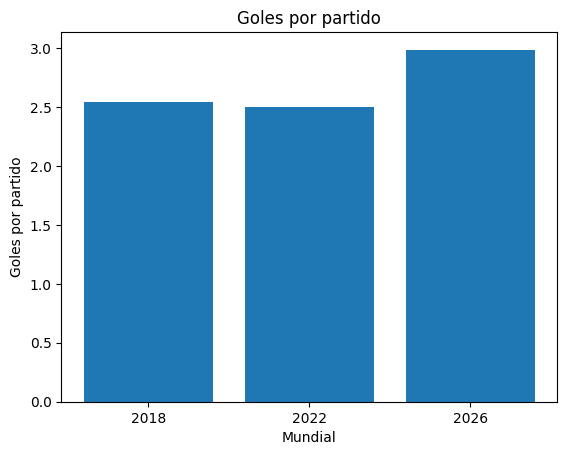

In [12]:
# TODO: crea una tabla con:
# partidos, goles, goles_por_partido, empates y porcentaje_empates.
comparacion = partidos.groupby('mundial').agg(
    partidos=('partido_id', 'count'),
    goles=('goles_totales', 'sum'),
    empates=('resultado_local', lambda s: (s == 'Empata').sum()),
).reset_index()

comparacion['goles_por_partido'] = comparacion['goles'] / comparacion['partidos']
comparacion['porcentaje_empates'] = comparacion['empates'] / comparacion['partidos']

comparacion

# TODO: grafica goles por partido.
# No compares únicamente goles totales: 2026 tiene más partidos.
fig, ax = plt.subplots()
ax.bar(comparacion['mundial'].astype(str), comparacion['goles_por_partido'])
ax.set_xlabel('Mundial')
ax.set_ylabel('Goles por partido')
ax.set_title('Goles por partido')
plt.show()


## Tabla por equipo

In [13]:
# TODO: convierte cada partido en dos apariciones de equipo:
# una para el local y otra para el visitante.
locales = partidos[['mundial', 'equipo_local', 'goles_local', 'goles_visitante', 'resultado_local']].rename(
    columns={'equipo_local': 'equipo', 'goles_local': 'gf', 'goles_visitante': 'gc'}
)
locales['puntos'] = np.select(
    [locales['resultado_local'] == 'Gana', locales['resultado_local'] == 'Empata'],
    [3, 1],
    default=0,
)

visitantes = partidos[['mundial', 'equipo_visitante', 'goles_visitante', 'goles_local', 'resultado_local']].rename(
    columns={'equipo_visitante': 'equipo', 'goles_visitante': 'gf', 'goles_local': 'gc'}
)
visitantes['puntos'] = np.select(
    [visitantes['resultado_local'] == 'Pierde', visitantes['resultado_local'] == 'Empata'],
    [3, 1],
    default=0,
)

apariciones = pd.concat([locales, visitantes], ignore_index=True)
tabla_equipos = apariciones.groupby(['mundial', 'equipo']).agg(
    pj=('equipo', 'count'),
    pg=('puntos', lambda s: (s == 3).sum()),
    pe=('puntos', lambda s: (s == 1).sum()),
    pp=('puntos', lambda s: (s == 0).sum()),
    gf=('gf', 'sum'),
    gc=('gc', 'sum'),
    pts=('puntos', 'sum'),
).reset_index()

tabla_equipos['dg'] = tabla_equipos['gf'] - tabla_equipos['gc']
tabla_equipos['pts_por_partido'] = tabla_equipos['pts'] / tabla_equipos['pj']

tabla_equipos.sort_values(['mundial', 'pts'], ascending=[True, False])


,mundial,equipo,pj,pg,pe,pp,gf,gc,pts,dg,pts_por_partido
2,2018,Belgium,3,3,0,0,9.0,2.0,9,7.0,3.000000
6,2018,Croatia,3,3,0,0,7.0,1.0,9,6.0,3.000000
31,2018,Uruguay,3,3,0,0,5.0,0.0,9,5.0,3.000000
3,2018,Brazil,3,2,1,0,5.0,1.0,7,4.0,2.333333
10,2018,France,3,2,1,0,3.0,1.0,7,2.0,2.333333
...,...,...,...,...,...,...,...,...,...,...,...
86,2026,Iraq,3,0,0,3,1.0,12.0,0,-11.0,0.000000
89,2026,Jordan,3,0,0,3,3.0,8.0,0,-5.0,0.000000
95,2026,Panama,3,0,0,3,0.0,4.0,0,-4.0,0.000000
107,2026,Tunisia,3,0,0,3,2.0,12.0,0,-10.0,0.000000


## Variables previas al partido

Para predecir no podemos utilizar datos ocurridos después del inicio. Crearemos promedios acumulados antes de cada encuentro.

In [14]:
def construir_variables_previas(partidos):
    # TODO: recorre cada torneo en orden cronológico.
    partidos = partidos.sort_values(['mundial', 'fecha', 'jornada']).reset_index(drop=True)

    estado = {}  # equipo -> {'pj': int, 'pts': int, 'gf': int, 'gc': int}

    def obtener_estado(equipo):
        return estado.setdefault(equipo, {'pj': 0, 'pts': 0, 'gf': 0, 'gc': 0})

    def promedios(e):
        if e['pj'] == 0:
            return np.nan, np.nan, np.nan
        return e['pts'] / e['pj'], (e['gf'] - e['gc']) / e['pj'], e['gf'] / e['pj']

    filas = []
    for _, fila in partidos.iterrows():
        local = obtener_estado(fila['equipo_local'])
        visita = obtener_estado(fila['equipo_visitante'])

        local_pts_prom_pre, local_gd_prom_pre, local_gf_prom_pre = promedios(local)
        visita_pts_prom_pre, visita_gd_prom_pre, visita_gf_prom_pre = promedios(visita)

        filas.append({
            **fila.to_dict(),
            'local_pts_prom_pre': local_pts_prom_pre,
            'local_gd_prom_pre': local_gd_prom_pre,
            'local_gf_prom_pre': local_gf_prom_pre,
            'visita_pts_prom_pre': visita_pts_prom_pre,
            'visita_gd_prom_pre': visita_gd_prom_pre,
            'visita_gf_prom_pre': visita_gf_prom_pre,
        })

        pts_local = 3 if fila['resultado_local'] == 'Gana' else (1 if fila['resultado_local'] == 'Empata' else 0)
        pts_visita = 3 if fila['resultado_local'] == 'Pierde' else (1 if fila['resultado_local'] == 'Empata' else 0)

        local['pj'] += 1
        local['pts'] += pts_local
        local['gf'] += fila['goles_local']
        local['gc'] += fila['goles_visitante']

        visita['pj'] += 1
        visita['pts'] += pts_visita
        visita['gf'] += fila['goles_visitante']
        visita['gc'] += fila['goles_local']

    return pd.DataFrame(filas)

features_df = construir_variables_previas(partidos)


## Entrenamiento y prueba

Línea base (predecir siempre 'Pierde'): 0.250
Precisión del árbol sobre 2026: 0.306


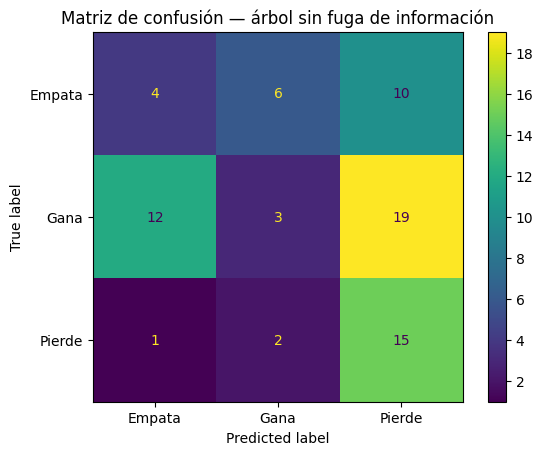

In [16]:
features = [
    'jornada',
    'local_pts_prom_pre', 'visita_pts_prom_pre',
    'local_gd_prom_pre', 'visita_gd_prom_pre',
    'local_gf_prom_pre', 'visita_gf_prom_pre',
    'local_es_anfitrion', 'visitante_es_anfitrion'
]

# Rellenar jornada 1 (sin historial previo) con 0
datos_modelo = features_df.copy()
for col in features:
    if datos_modelo[col].dtype == bool:
        continue
    datos_modelo[col] = datos_modelo[col].fillna(0)

# Separar train (2018+2022) y test (2026)
train = datos_modelo[datos_modelo['mundial'].isin([2018, 2022])]
test = datos_modelo[datos_modelo['mundial'] == 2026]

X_train, y_train = train[features], train['resultado_local']
X_test, y_test = test[features], test['resultado_local']

# Línea base: precisión de predecir siempre la clase más frecuente
clase_mayoritaria = y_train.value_counts().idxmax()
linea_base = (y_test == clase_mayoritaria).mean()
print(f"Línea base (predecir siempre '{clase_mayoritaria}'): {linea_base:.3f}")

# Entrenar árbol
modelo = DecisionTreeClassifier(max_depth=4, min_samples_leaf=5, random_state=0)
modelo.fit(X_train, y_train)

y_pred = modelo.predict(X_test)
precision = accuracy_score(y_test, y_pred)
print(f"Precisión del árbol sobre 2026: {precision:.3f}")

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title('Matriz de confusión — árbol sin fuga de información')
plt.show()


## Experimento de fuga de información

Agrega temporalmente `goles_local`, `goles_visitante` y `diferencia_goles` como variables. Si la precisión sube de forma extrema, explica por qué el modelo no está prediciendo realmente.

Precisión SIN fuga: 0.306
Precisión CON fuga: 1.000


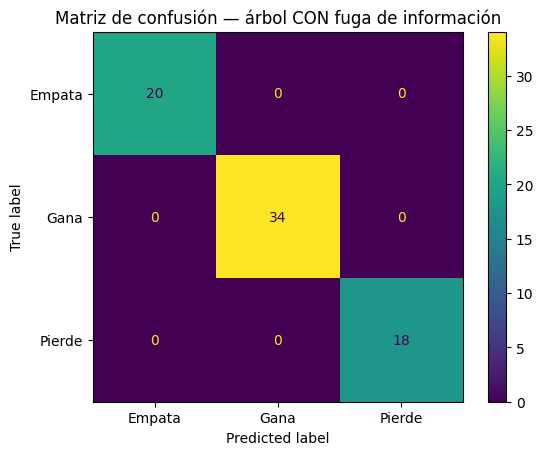

In [17]:
# TODO: ejecuta el experimento con fuga y compara.
features_fuga = features + ['goles_local', 'goles_visitante', 'diferencia_goles']

train_fuga = datos_modelo[datos_modelo['mundial'].isin([2018, 2022])]
test_fuga = datos_modelo[datos_modelo['mundial'] == 2026]

X_train_fuga, y_train_fuga = train_fuga[features_fuga], train_fuga['resultado_local']
X_test_fuga, y_test_fuga = test_fuga[features_fuga], test_fuga['resultado_local']

modelo_fuga = DecisionTreeClassifier(max_depth=4, min_samples_leaf=5, random_state=0)
modelo_fuga.fit(X_train_fuga, y_train_fuga)

y_pred_fuga = modelo_fuga.predict(X_test_fuga)
precision_fuga = accuracy_score(y_test_fuga, y_pred_fuga)

print(f"Precisión SIN fuga: {precision:.3f}")
print(f"Precisión CON fuga: {precision_fuga:.3f}")

ConfusionMatrixDisplay.from_predictions(y_test_fuga, y_pred_fuga)
plt.title('Matriz de confusión — árbol CON fuga de información')
plt.show()


# Explicacion
resultado_local se define matemáticamente como una función directa de goles_local y goles_visitante (Gana si goles_local > goles_visitante, etc. — literalmente la fórmula que usaste en Excel para la columna resultado_local). Al meter esos mismos goles como features de entrada, no le estás dando al árbol "información previa útil para predecir" — le estás dando la respuesta ya calculada, disfrazada de pregunta. El árbol no aprendió ningún patrón de fútbol; solo encontró el atajo si goles_local > goles_visitante entonces Gana, que es trivialmente cierto por construcción, no por relación causal aprendida.

## Reflexión final

Responde:

- ¿Qué problema de calidad fue el más difícil?
    Lo mas dificil fue unificar las fechas de 5 formatos a uno solo.
- ¿Qué decisión de limpieza podría cambiar los resultados?
    rellenar promedios previos de la jornada 1 con 0, porque eso implica "sin nivel" y no un neutral.
- ¿Por qué 2026 debe compararse mediante tasas?
    Porque tiene mas clubes, por ende mas partidos y todas las estadisticas suben
- ¿El árbol supera la línea base?
    Sin fuga tuvo bastante precision pero basto con unas modificaciones para mostrar muchos datos erroneos.
- ¿Qué variables reales agregarías para mejorar una predicción?
    Ranking FIFA, ultimos 5 resultados, frente a frente
- ¿Por qué un resultado de 100 % puede ser una señal de alarma?
    Porque con tantas variables es imposible que todo cuadre a un mismo resultado.